# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [49]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

In [51]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [52]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [53]:
df.shape

(3150, 14)

In [54]:
TARGET_COLUMN = 'Churn' # preencher

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

,count
Churn,
0,2655
1,495


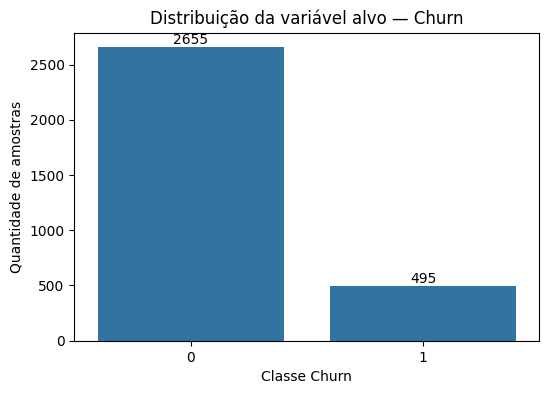

In [55]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
display(class_counts_bin)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=TARGET_COLUMN, order=class_counts_bin.index)
plt.title("Distribuição da variável alvo — Churn")
plt.xlabel("Classe Churn")
plt.ylabel("Quantidade de amostras")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [56]:
print("Proporção por classe:")
display((class_counts / len(df) * 100).round(2))

Proporção por classe:


,count
Churn,
0,84.29
1,15.71


O dataset é **desbalanceado**, pois a classe `0` possui muito mais amostras do que a classe `1`. Isso indica que há muito mais clientes que não cancelaram o serviço do que clientes que cancelaram. Esse desbalanceamento é importante porque um modelo pode obter alta acurácia apenas favorecendo a classe majoritária, por isso métricas como **precisão**, **recall** e **F1-score** são mais adequadas para complementar a análise.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

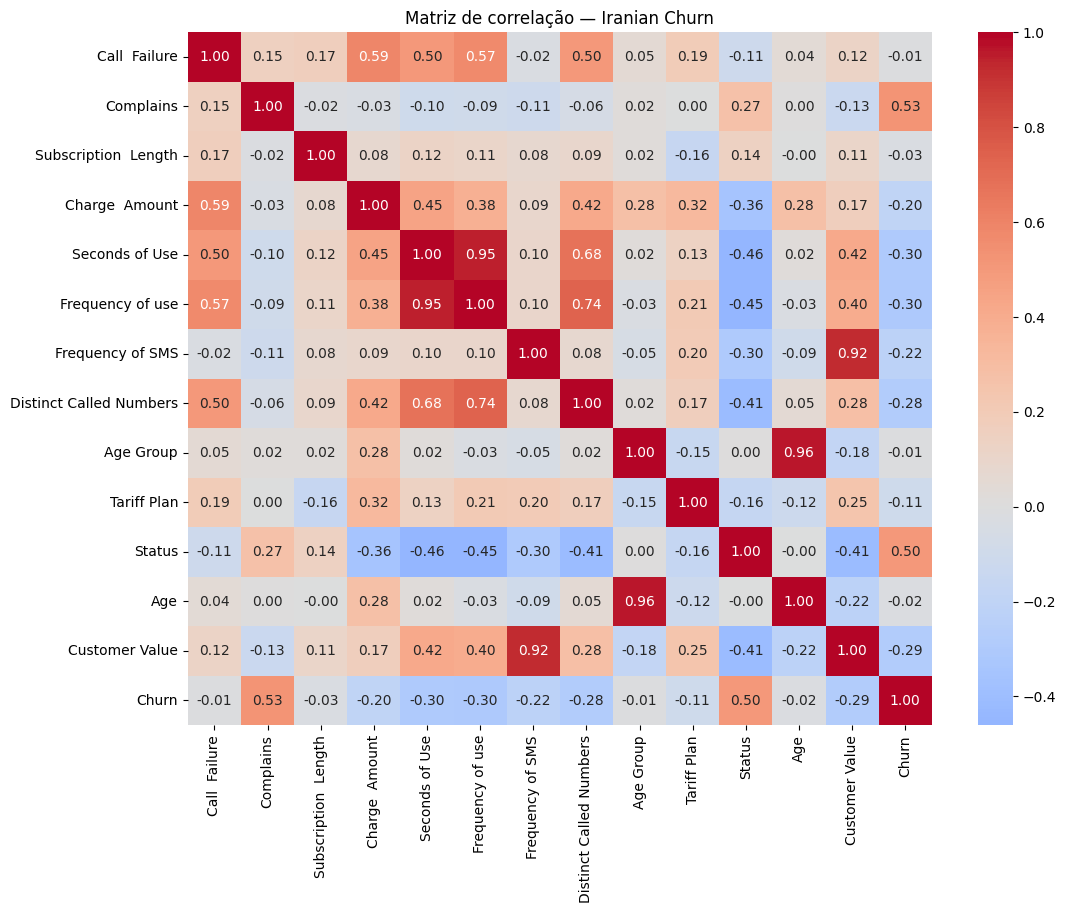

In [57]:
corr_matriz = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação — Iranian Churn")
plt.show()

In [58]:
target_corr = (
    corr_matriz[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Correlação dos atributos com Churn, ordenada por valor absoluto:")
display(target_corr)

Correlação dos atributos com Churn, ordenada por valor absoluto:


,Churn
Complains,0.532053
Status,0.498976
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754
Charge Amount,-0.202305
Tariff Plan,-0.105853
Subscription Length,-0.032588


Os atributos mais relevantes são aqueles com maior correlação em valor absoluto com `Churn`. Correlações positivas indicam que, quando o atributo aumenta, a chance de `Churn = 1` tende a aumentar. Correlações negativas indicam relação inversa. Em geral, variáveis como `Complains` e `Status` tendem a apresentar forte relação positiva com churn, enquanto variáveis relacionadas ao uso e ao valor do cliente podem apresentar correlação negativa, indicando que clientes mais ativos ou de maior valor tendem a cancelar menos. A análise deve considerar os valores impressos na tabela de correlações para identificar precisamente os atributos mais influentes.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

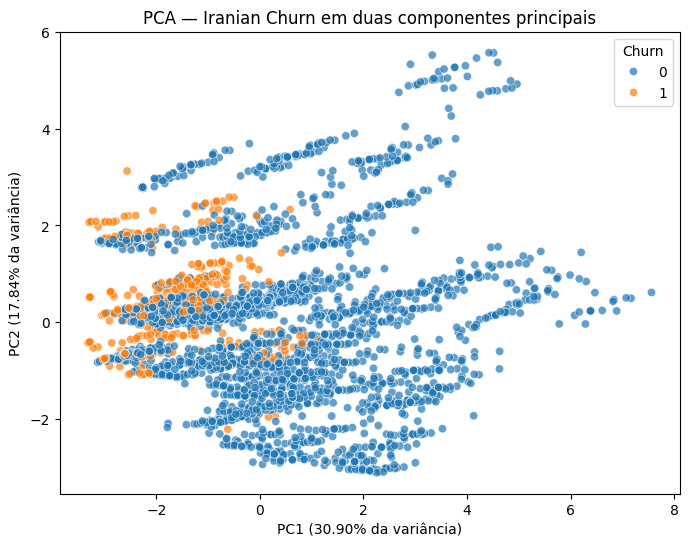

Variância explicada pelas duas primeiras componentes:
[0.30904449 0.17841786]
Variância total explicada: 0.4874623541704386


In [59]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Churn": y.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Churn",
    alpha=0.7
)
plt.title("PCA — Iranian Churn em duas componentes principais")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% da variância)")
plt.show()

print("Variância explicada pelas duas primeiras componentes:")
print(pca.explained_variance_ratio_)
print("Variância total explicada:", pca.explained_variance_ratio_.sum())

A projeção em duas dimensões por PCA permite visualizar se as classes apresentam separação no espaço reduzido. Caso os pontos das classes `0` e `1` apareçam bastante misturados, isso indica que não há separação linear clara apenas nas duas primeiras componentes principais. Portanto, mesmo que exista alguma tendência de agrupamento, há sobreposição entre as classes, o que torna o problema mais difícil e justifica o uso de modelos supervisionados para aprender combinações dos atributos.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [60]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)
print("Distribuição no treino:")
display(y_train.value_counts(normalize=True).sort_index())
print("Distribuição no teste:")
display(y_test.value_counts(normalize=True).sort_index())

Treino: (2520, 13)
Teste: (630, 13)
Distribuição no treino:


,proportion
Churn,
0,0.842857
1,0.157143


Distribuição no teste:


,proportion
Churn,
0,0.842857
1,0.157143


A padronização é importante porque a regressão logística é sensível à escala dos atributos. Como as variáveis possuem unidades e intervalos muito diferentes, a padronização transforma os atributos para uma escala comum, com média próxima de 0 e desvio padrão próximo de 1. O `fit` deve ser aplicado apenas no conjunto de treino para evitar **vazamento de dados**. Se o scaler fosse ajustado usando também o conjunto de teste, informações estatísticas do teste seriam usadas durante o treinamento, tornando a avaliação artificialmente otimista.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [61]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Número de iterações realizadas:", model.n_iter_)
print("Máximo de iterações permitido:", model.max_iter)

if np.all(model.n_iter_ < model.max_iter):
    print("O modelo convergiu corretamente.")
else:
    print("Atenção: o modelo pode não ter convergido.")

Número de iterações realizadas: [39]
Máximo de iterações permitido: 1000
O modelo convergiu corretamente.


A regressão logística está sendo usada para estimar a probabilidade de um cliente pertencer à classe `Churn = 1`. No contexto do problema, o modelo aprende uma combinação ponderada dos atributos de entrada para separar clientes que cancelam daqueles que não cancelam. Os coeficientes aprendidos representam a influência de cada atributo na decisão do modelo. A verificação de convergência indica se o algoritmo conseguiu encontrar uma solução estável dentro do número máximo de iterações.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [62]:
proba = model.predict_proba(X_test_scaled)

proba_df = pd.DataFrame(
    proba[:10],
    columns=[f"P(Churn={classe})" for classe in model.classes_]
)

display(proba_df)

,P(Churn=0),P(Churn=1)
0,0.873777,0.126223
1,0.999172,0.000828
2,0.974711,0.025289
3,0.994281,0.005719
4,0.997312,0.002688
5,0.651022,0.348978
6,0.976326,0.023674
7,0.979422,0.020578
8,0.986777,0.013223
9,0.813181,0.186819


Cada linha representa uma amostra do conjunto de teste. A primeira coluna indica a probabilidade prevista para a classe `0`, isto é, cliente que não cancelou. A segunda coluna indica a probabilidade prevista para a classe `1`, isto é, cliente que cancelou. Quando uma das probabilidades está muito próxima de 1 e a outra muito próxima de 0, o modelo está fazendo uma previsão com alta confiança. Quando os valores estão próximos de 0,5, a previsão é mais incerta.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [63]:
idx_pos = list(model.classes_).index(1)
proba_churn = proba[:, idx_pos]

y_pred_05 = (proba_churn >= 0.5).astype(int)
y_pred_07 = (proba_churn >= 0.7).astype(int)

print("Distribuição das previsões com limiar 0.5:")
display(pd.Series(y_pred_05).value_counts().sort_index())

print("Distribuição das previsões com limiar 0.7:")
display(pd.Series(y_pred_07).value_counts().sort_index())

Distribuição das previsões com limiar 0.5:


,count
0,580
1,50


Distribuição das previsões com limiar 0.7:


,count
0,595
1,35


Ao usar limiar `0.5`, o modelo classifica como churn todos os clientes cuja probabilidade prevista para `Churn = 1` seja pelo menos 50%. Ao aumentar o limiar para `0.7`, o modelo fica mais conservador para prever churn, exigindo maior confiança para classificar um cliente como cancelador. Com isso, a tendência é reduzir falsos positivos, mas aumentar falsos negativos, pois alguns clientes que realmente cancelariam podem deixar de ser classificados como churn.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

=== Limiar 0.5 ===
Acurácia: 0.8968
Precisão: 0.8400
Recall:   0.4242
F1-score: 0.5638
Matriz de confusão:
[[523   8]
 [ 57  42]]


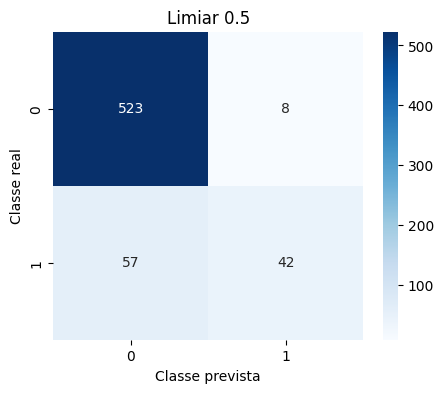

=== Limiar 0.7 ===
Acurácia: 0.8984
Precisão: 1.0000
Recall:   0.3535
F1-score: 0.5224
Matriz de confusão:
[[531   0]
 [ 64  35]]


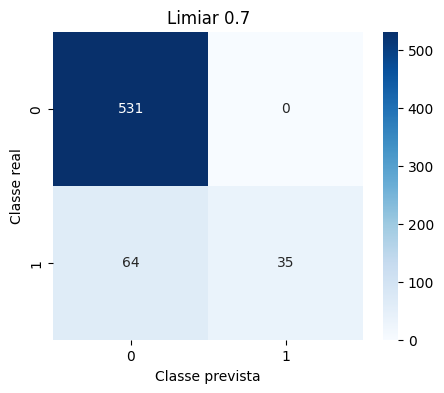

,limiar,acuracia,precisao,recall,f1
0,Limiar 0.5,0.896825,0.84,0.424242,0.563758
1,Limiar 0.7,0.898413,1.00,0.353535,0.522388


In [64]:
def avaliar_binario(y_true, y_pred, titulo):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {titulo} ===")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Matriz de confusão:")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(titulo)
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

    return {
        "limiar": titulo,
        "acuracia": acc,
        "precisao": prec,
        "recall": rec,
        "f1": f1
    }

result_05 = avaliar_binario(y_test, y_pred_05, "Limiar 0.5")
result_07 = avaliar_binario(y_test, y_pred_07, "Limiar 0.7")

display(pd.DataFrame([result_05, result_07]))

A mudança do limiar altera principalmente o equilíbrio entre **precisão** e **recall**. Ao aumentar o limiar de `0.5` para `0.7`, o modelo tende a prever menos casos positivos. Isso pode aumentar a precisão, pois as previsões positivas ficam mais conservadoras, mas geralmente reduz o recall, pois mais clientes que realmente pertencem à classe `1` deixam de ser detectados. Portanto, a escolha do limiar depende do objetivo do problema: se for mais importante capturar o máximo possível de clientes propensos ao cancelamento, o recall deve ser priorizado; se for mais importante evitar alarmes falsos, a precisão deve ser priorizada.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [65]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [66]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [67]:
df.shape

(58101, 55)

In [68]:
TARGET_COLUMN = 'Cover_Type'

O dataframe resultante possui aproximadamente **58 mil amostras** e **55 colunas**, sendo **54 atributos de entrada** e **1 variável alvo**. A variável alvo é `Cover_Type`. O problema **não é binário**, pois a variável alvo assume sete valores possíveis, de `1` a `7`. Portanto, trata-se de um problema de **classificação multiclasse**.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

,count
Cover_Type,
1,21297
2,28248
3,3607
4,259
5,932
6,1706
7,2052


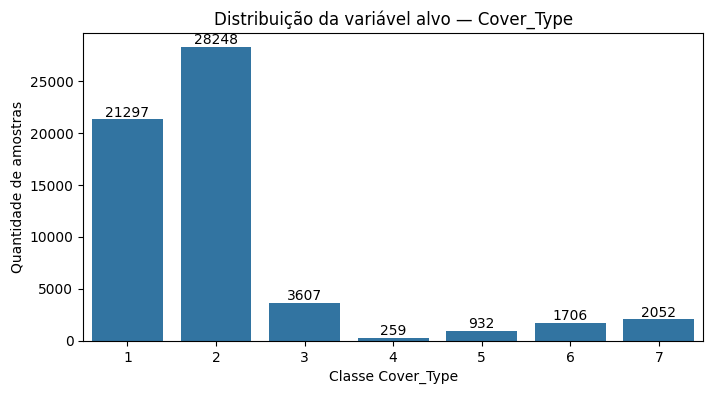

In [69]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df,
    x=TARGET_COLUMN,
    order=class_counts.index
)
plt.title("Distribuição da variável alvo — Cover_Type")
plt.xlabel("Classe Cover_Type")
plt.ylabel("Quantidade de amostras")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [70]:
print("Proporção por classe:")
display((class_counts / len(df) * 100).round(2))

Proporção por classe:


,count
Cover_Type,
1,36.66
2,48.62
3,6.21
4,0.45
5,1.60
6,2.94
7,3.53


O dataset é **desbalanceado**, pois algumas classes de cobertura florestal aparecem com frequência muito maior do que outras. Normalmente, as classes `1` e `2` concentram grande parte das amostras, enquanto classes como `4` e `5` aparecem em quantidade bem menor. Esse desbalanceamento pode afetar o desempenho do modelo, principalmente nas classes minoritárias, tornando importante avaliar métricas por classe, e não apenas a acurácia global.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

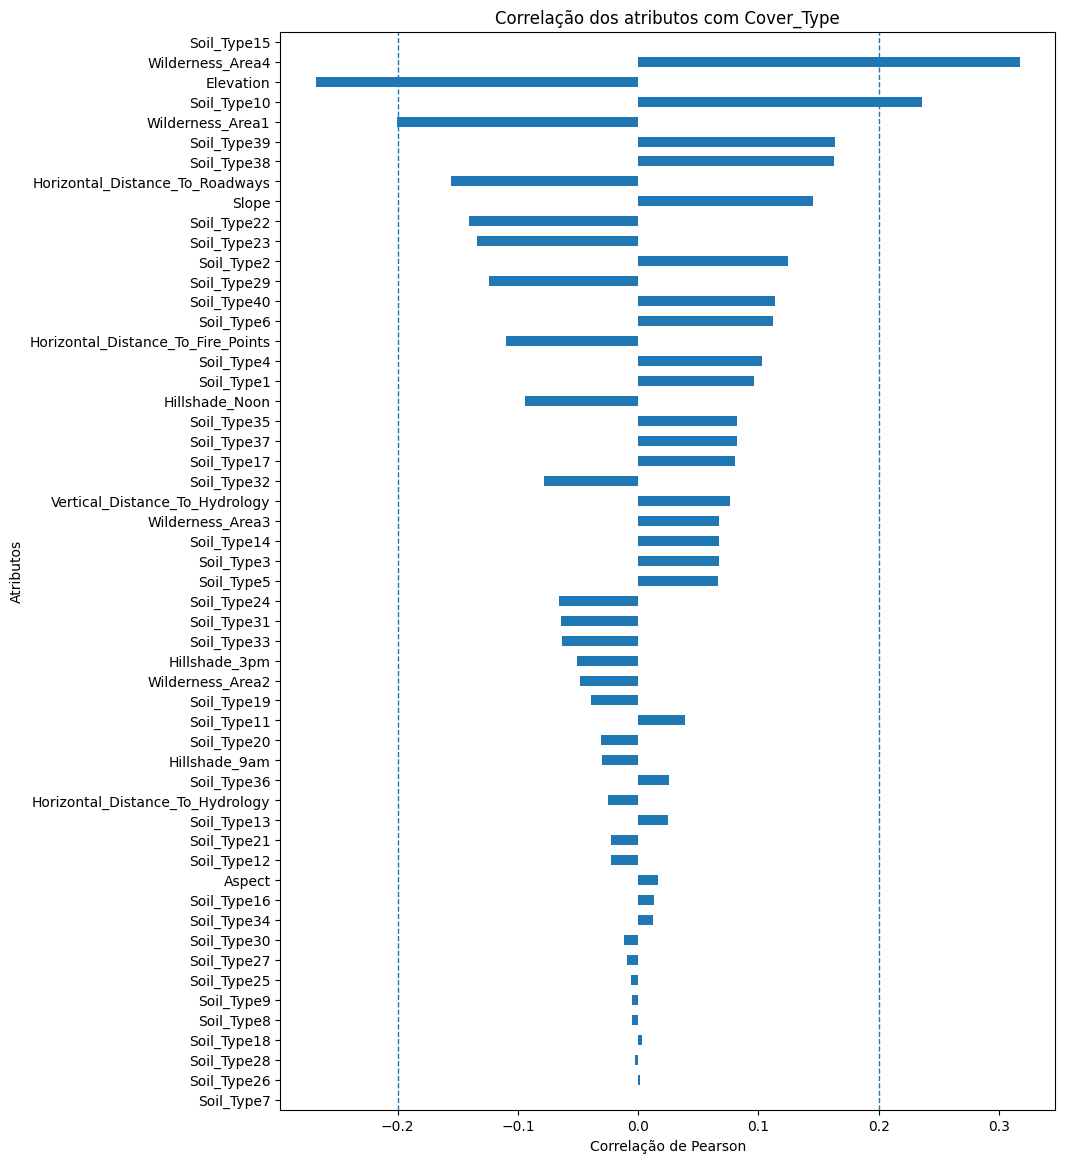

In [71]:
corr = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)
corr_sorted = corr.sort_values(key=lambda s: s.abs(), ascending=True)

plt.figure(figsize=(10, 14))
corr_sorted.plot(kind="barh")
plt.axvline(0.2, linestyle="--", linewidth=1)
plt.axvline(-0.2, linestyle="--", linewidth=1)
plt.title("Correlação dos atributos com Cover_Type")
plt.xlabel("Correlação de Pearson")
plt.ylabel("Atributos")
plt.show()


In [72]:
print("Correlação ordenada por valor absoluto:")
display(corr.sort_values(key=lambda s: s.abs(), ascending=False))

Correlação ordenada por valor absoluto:


,Cover_Type
Wilderness_Area4,0.317518
Elevation,-0.268264
Soil_Type10,0.236392
Wilderness_Area1,-0.200715
Soil_Type39,0.163504
Soil_Type38,0.162663
Horizontal_Distance_To_Roadways,-0.155258
Slope,0.145731
Soil_Type22,-0.140253
Soil_Type23,-0.133668


Os atributos mais relevantes são aqueles com maior correlação em valor absoluto com `Cover_Type`. As linhas de referência em `|r| = 0.2` ajudam a destacar correlações moderadas. Entretanto, como `Cover_Type` é uma variável categórica codificada com números de `1` a `7`, a correlação de Pearson deve ser interpretada com cuidado, pois os números das classes não representam necessariamente uma ordem quantitativa real. Ainda assim, variáveis como elevação, áreas de preservação, tipos de solo e distâncias cartográficas podem aparecer como relevantes para diferenciar os tipos de cobertura.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

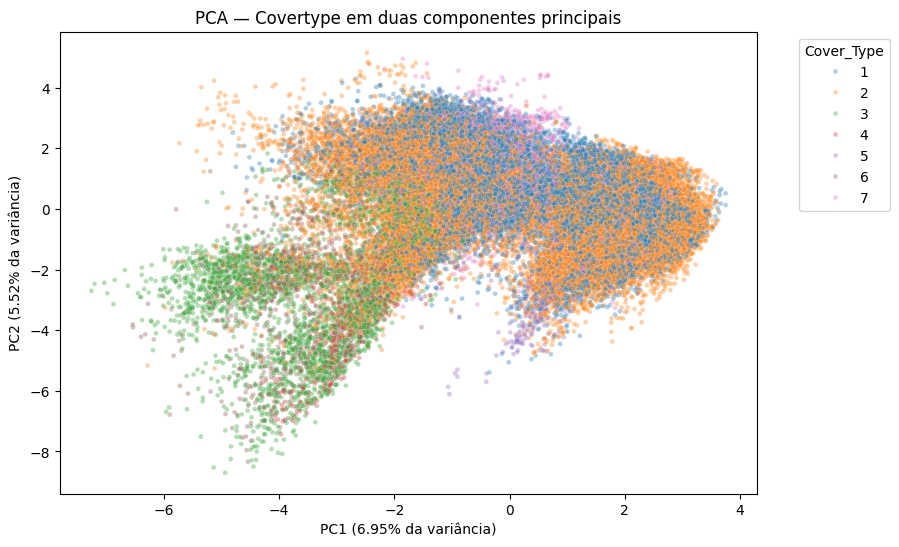

Variância explicada pelas duas primeiras componentes:
[0.06948199 0.05517254]
Variância total explicada: 0.12465453211189659


In [73]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cover_Type": y.values
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cover_Type",
    palette="tab10",
    alpha=0.35,
    s=12
)
plt.title("PCA — Covertype em duas componentes principais")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% da variância)")
plt.legend(title="Cover_Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

print("Variância explicada pelas duas primeiras componentes:")
print(pca.explained_variance_ratio_)
print("Variância total explicada:", pca.explained_variance_ratio_.sum())

A visualização por PCA permite observar a distribuição das classes em duas dimensões, mas normalmente há forte sobreposição entre os grupos. Isso indica que as duas primeiras componentes principais não são suficientes para separar perfeitamente as sete classes. Portanto, a classificação multiclasse exige o uso do conjunto completo de atributos, pois a separação entre os tipos de cobertura depende de combinações mais complexas das variáveis cartográficas.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [74]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Número de folds:", kf.get_n_splits())

Treino: (46480, 54)
Teste: (11621, 54)
Número de folds: 5


A validação cruzada k-fold é importante porque avalia o modelo em diferentes partições do conjunto de treino, reduzindo a dependência de uma única divisão treino/validação. Com isso, a estimativa de desempenho se torna mais robusta. Em vez de confiar em apenas uma validação, o modelo é treinado e avaliado várias vezes, permitindo calcular médias de métricas como acurácia, precisão, recall e F1-score.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [75]:
metrics_folds = []
max_iter_cv = 1000

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Padronização dentro do fold, evitando vazamento de dados
    scaler_fold = StandardScaler()
    X_tr_scaled = scaler_fold.fit_transform(X_tr)
    X_val_scaled = scaler_fold.transform(X_val)

    model_fold = LogisticRegression(
        max_iter=max_iter_cv,
        solver="lbfgs",
        random_state=42
    )

    model_fold.fit(X_tr_scaled, y_tr)
    y_val_pred = model_fold.predict(X_val_scaled)

    print(f"Fold {fold}")
    print("n_iter_:", model_fold.n_iter_)
    if np.all(model_fold.n_iter_ < max_iter_cv):
        print("Convergiu corretamente.")
    else:
        print("Atenção: pode não ter convergido.")
    print("-" * 50)

    metrics_folds.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision_macro": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    })

df_metrics_folds = pd.DataFrame(metrics_folds)
display(df_metrics_folds)

print("Média das métricas:")
display(df_metrics_folds.drop(columns=["fold"]).mean())

Fold 1
n_iter_: [211]
Convergiu corretamente.
--------------------------------------------------
Fold 2
n_iter_: [185]
Convergiu corretamente.
--------------------------------------------------
Fold 3
n_iter_: [180]
Convergiu corretamente.
--------------------------------------------------
Fold 4
n_iter_: [206]
Convergiu corretamente.
--------------------------------------------------
Fold 5
n_iter_: [214]
Convergiu corretamente.
--------------------------------------------------


,fold,accuracy,precision_macro,recall_macro,f1_macro
0,1,0.723429,0.581015,0.514348,0.536018
1,2,0.732358,0.613993,0.485148,0.501153
2,3,0.733111,0.571946,0.505384,0.523827
3,4,0.721170,0.554791,0.501841,0.519330
4,5,0.721601,0.550046,0.488196,0.507301


Média das métricas:


,0
accuracy,0.726334
precision_macro,0.574358
recall_macro,0.498983
f1_macro,0.517526


A regressão logística multiclasse aprende fronteiras de decisão para separar as sete classes de cobertura florestal com base nos atributos cartográficos. Em cada fold, o modelo é treinado em uma parte do conjunto de treino e validado em outra. A média das métricas fornece uma visão mais confiável do desempenho esperado. O número de iterações `n_iter_` mostra quantas iterações o otimizador utilizou; se esse valor for menor que `max_iter`, o modelo convergiu dentro do limite definido.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [76]:
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train)
X_test_final_scaled = scaler_final.transform(X_test)

model_l2 = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    C=0.01,
    random_state=42
)

model_l2.fit(X_train_final_scaled, y_train)

proba_l2 = model_l2.predict_proba(X_test_final_scaled)

sample_idx = np.arange(10)

proba_l2_df = pd.DataFrame(
    proba_l2[sample_idx],
    columns=[f"P(classe={classe})" for classe in model_l2.classes_]
)

display(proba_l2_df)

print("Classes do modelo:", model_l2.classes_)
print("n_iter_:", model_l2.n_iter_)

,P(classe=1),P(classe=2),P(classe=3),P(classe=4),P(classe=5),P(classe=6),P(classe=7)
0,0.041691,0.943197,0.000391,0.000212,0.010645,0.003342,0.000521
1,0.282855,0.693445,0.000704,0.000128,0.008763,0.007415,0.006688
2,0.411363,0.579304,0.000146,0.000142,0.007285,0.000642,0.001119
3,0.106840,0.847547,0.000342,0.000376,0.041606,0.001048,0.002242
4,0.083566,0.892183,0.000140,0.000211,0.020183,0.001379,0.002338
5,0.343433,0.621162,0.002538,0.000327,0.012425,0.014821,0.005293
6,0.630515,0.344695,0.000757,0.000118,0.007178,0.008498,0.008239
7,0.411285,0.585799,0.000034,0.000073,0.000550,0.000307,0.001953
8,0.846001,0.141799,0.000019,0.000033,0.004240,0.000019,0.007889
9,0.483031,0.506780,0.000927,0.000848,0.001972,0.003825,0.002617


Classes do modelo: [1 2 3 4 5 6 7]
n_iter_: [92]


Cada coluna da matriz de probabilidades representa uma classe possível de `Cover_Type`. Cada linha representa uma amostra do conjunto de teste, e a soma das probabilidades da linha é igual a 1. A classe prevista é aquela com maior probabilidade. Com regularização L2 e `C = 0.01`, o modelo fica mais restrito, pois coeficientes muito grandes são penalizados. Isso tende a produzir previsões menos extremas e pode reduzir overfitting.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [77]:
model_no_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    penalty=None,
    random_state=42
)

model_no_reg.fit(X_train_final_scaled, y_train)

proba_no_reg = model_no_reg.predict_proba(X_test_final_scaled)

proba_no_reg_df = pd.DataFrame(
    proba_no_reg[sample_idx],
    columns=[f"P(classe={classe})" for classe in model_no_reg.classes_]
)

display(proba_no_reg_df)

print("Classes do modelo:", model_no_reg.classes_)
print("n_iter_:", model_no_reg.n_iter_)

,P(classe=1),P(classe=2),P(classe=3),P(classe=4),P(classe=5),P(classe=6),P(classe=7)
0,0.028513,0.956341,8.196597e-06,1.987976e-05,0.015094,2.231821e-05,1.281724e-06
1,0.269631,0.718041,2.562157e-06,4.037514e-06,0.007613,4.519016e-03,1.892740e-04
2,0.378618,0.613714,1.559695e-07,2.239278e-06,0.007649,7.989018e-07,1.509210e-05
3,0.091396,0.871393,2.681404e-07,9.258946e-07,0.037168,3.571109e-07,4.176599e-05
4,0.069617,0.912152,3.196709e-07,2.447031e-05,0.018171,1.937357e-06,3.422224e-05
5,0.325941,0.657362,8.649578e-06,1.158521e-06,0.009585,6.993296e-03,1.087319e-04
6,0.664991,0.329889,2.025912e-07,7.467826e-10,0.003679,3.832498e-04,1.057049e-03
7,0.386653,0.612856,1.628154e-08,7.273459e-05,0.000354,1.330098e-06,6.274424e-05
8,0.873343,0.114602,1.813833e-10,2.170915e-11,0.002474,1.718461e-10,9.581431e-03
9,0.498255,0.501073,4.197151e-06,2.463623e-06,0.000662,2.487490e-06,5.061546e-07


Classes do modelo: [1 2 3 4 5 6 7]
n_iter_: [214]


O modelo sem regularização não penaliza coeficientes grandes. Por isso, ele pode gerar probabilidades mais concentradas em uma única classe, indicando maior confiança nas previsões. Entretanto, confiança maior nem sempre significa melhor generalização. Sem regularização, o modelo pode se ajustar excessivamente ao conjunto de treino, aumentando o risco de overfitting.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

Confiança média com regularização L2 (C=0.01): 0.7033
Confiança média sem regularização: 0.7270


,modelo,confianca_media,confianca_mediana,confianca_minima,confianca_maxima
0,L2 C=0.01,0.703261,0.703591,0.271775,0.997372
1,Sem regularização,0.726978,0.735002,0.336224,1.000000


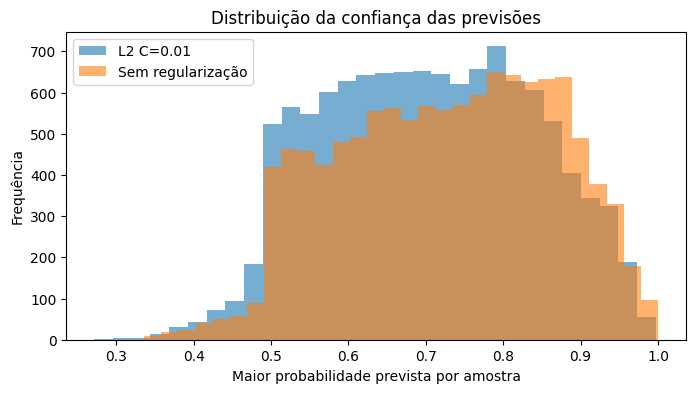

In [78]:
conf_l2 = proba_l2.max(axis=1)
conf_no_reg = proba_no_reg.max(axis=1)

print(f"Confiança média com regularização L2 (C=0.01): {conf_l2.mean():.4f}")
print(f"Confiança média sem regularização: {conf_no_reg.mean():.4f}")

comparison_conf = pd.DataFrame({
    "modelo": ["L2 C=0.01", "Sem regularização"],
    "confianca_media": [conf_l2.mean(), conf_no_reg.mean()],
    "confianca_mediana": [np.median(conf_l2), np.median(conf_no_reg)],
    "confianca_minima": [conf_l2.min(), conf_no_reg.min()],
    "confianca_maxima": [conf_l2.max(), conf_no_reg.max()]
})

display(comparison_conf)

plt.figure(figsize=(8, 4))
plt.hist(conf_l2, bins=30, alpha=0.6, label="L2 C=0.01")
plt.hist(conf_no_reg, bins=30, alpha=0.6, label="Sem regularização")
plt.title("Distribuição da confiança das previsões")
plt.xlabel("Maior probabilidade prevista por amostra")
plt.ylabel("Frequência")
plt.legend()
plt.show()

A confiança média é calculada considerando, para cada amostra, a maior probabilidade prevista pelo modelo. Se o modelo sem regularização apresentar confiança média maior, isso indica que suas probabilidades estão mais concentradas em uma classe. Porém, isso pode ser um indício de overfitting caso a melhora de confiança não venha acompanhada de melhora nas métricas do conjunto de teste. O modelo com regularização tende a ser mais conservador e pode generalizar melhor, mesmo quando suas probabilidades são menos extremas.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [79]:
y_pred_l2 = model_l2.predict(X_test_final_scaled)
y_pred_no_reg = model_no_reg.predict(X_test_final_scaled)

print("=== Modelo com regularização L2 (C=0.01) ===")
print(classification_report(y_test, y_pred_l2, zero_division=0))

print("=== Modelo sem regularização ===")
print(classification_report(y_test, y_pred_no_reg, zero_division=0))

=== Modelo com regularização L2 (C=0.01) ===
              precision    recall  f1-score   support

           1       0.72      0.69      0.70      4260
           2       0.74      0.80      0.77      5650
           3       0.64      0.85      0.73       722
           4       0.46      0.21      0.29        52
           5       0.00      0.00      0.00       186
           6       0.48      0.14      0.22       341
           7       0.73      0.57      0.64       410

    accuracy                           0.72     11621
   macro avg       0.54      0.47      0.48     11621
weighted avg       0.70      0.72      0.71     11621

=== Modelo sem regularização ===
              precision    recall  f1-score   support

           1       0.72      0.70      0.71      4260
           2       0.75      0.80      0.77      5650
           3       0.68      0.79      0.73       722
           4       0.51      0.42      0.46        52
           5       0.00      0.00      0.00       186


O `classification_report` permite comparar precisão, recall e F1-score por classe. Em datasets desbalanceados, classes majoritárias costumam apresentar desempenho melhor, enquanto classes minoritárias podem ter recall e F1-score menores. A comparação entre os modelos mostra se a regularização melhora a generalização ou se o modelo sem regularização consegue maior desempenho. Caso o modelo sem regularização melhore apenas algumas classes e piore outras, é necessário avaliar o equilíbrio geral usando as médias `macro avg` e `weighted avg`.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

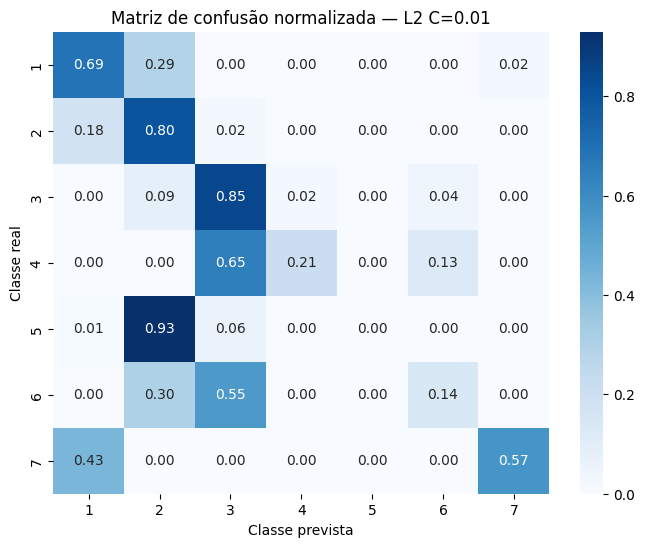

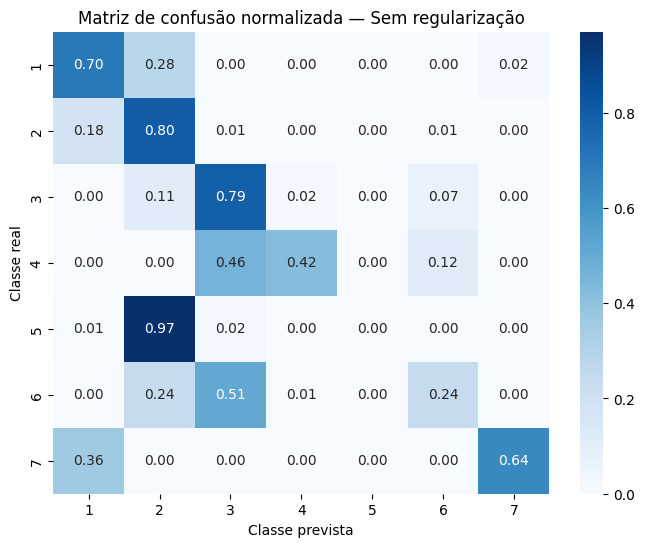

Matriz normalizada — L2 C=0.01


,1,2,3,4,5,6,7
1,0.69,0.29,0.00,0.00,0.0,0.00,0.02
2,0.18,0.80,0.02,0.00,0.0,0.00,0.00
3,0.00,0.09,0.85,0.02,0.0,0.04,0.00
4,0.00,0.00,0.65,0.21,0.0,0.13,0.00
5,0.01,0.93,0.06,0.00,0.0,0.00,0.00
6,0.00,0.30,0.55,0.00,0.0,0.14,0.00
7,0.43,0.00,0.00,0.00,0.0,0.00,0.57


Matriz normalizada — Sem regularização


,1,2,3,4,5,6,7
1,0.70,0.28,0.00,0.00,0.0,0.00,0.02
2,0.18,0.80,0.01,0.00,0.0,0.01,0.00
3,0.00,0.11,0.79,0.02,0.0,0.07,0.00
4,0.00,0.00,0.46,0.42,0.0,0.12,0.00
5,0.01,0.97,0.02,0.00,0.0,0.00,0.00
6,0.00,0.24,0.51,0.01,0.0,0.24,0.00
7,0.36,0.00,0.00,0.00,0.0,0.00,0.64


In [80]:
labels = sorted(y.unique())

cm_l2_norm = confusion_matrix(
    y_test,
    y_pred_l2,
    labels=labels,
    normalize="true"
)

cm_no_reg_norm = confusion_matrix(
    y_test,
    y_pred_no_reg,
    labels=labels,
    normalize="true"
)

cm_l2_norm_round = np.round(cm_l2_norm, 2)
cm_no_reg_norm_round = np.round(cm_no_reg_norm, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_l2_norm_round,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Matriz de confusão normalizada — L2 C=0.01")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_no_reg_norm_round,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Matriz de confusão normalizada — Sem regularização")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.show()

print("Matriz normalizada — L2 C=0.01")
display(pd.DataFrame(cm_l2_norm_round, index=labels, columns=labels))

print("Matriz normalizada — Sem regularização")
display(pd.DataFrame(cm_no_reg_norm_round, index=labels, columns=labels))

A matriz de confusão normalizada mostra, para cada classe real, a proporção de amostras classificadas em cada classe prevista. Valores altos na diagonal principal indicam bom desempenho. Valores fora da diagonal indicam confusão entre classes. As classes majoritárias tendem a ser melhor classificadas, enquanto classes minoritárias podem apresentar maior confusão. Comparando os modelos, a regularização pode reduzir erros causados por ajuste excessivo, mas também pode suavizar demais as fronteiras de decisão; já o modelo sem regularização pode ser mais confiante, porém mais propenso a overfitting.